# Wallclock Distribution Analysis

Statistical distribution analysis of `wallclock_requested` (a.k.a. `requested_seconds`) across
all runtime-prediction datasets. This analysis characterizes the natural clustering of wallclock
values at HPC partition limits, and assesses whether these clusters define meaningful job
populations with distinct runtime characteristics.

**Purpose:** Inform whether a mixture-of-experts approach (separate models per wallclock cluster)
would improve runtime prediction beyond what a single model with wallclock as a feature already achieves.

**Prerequisites:** This notebook requires downloaded datasets. If not available, run from `workspace/`:
```bash
hpc-oda datasets prepare <descriptor.yml> --cache .hpc_oda/cache/datasets --out .
```

**Related:** Issue [#124](https://github.com/NatLabRockies/hpc-oda-commons/issues/124)

## 1. Setup

In [13]:
import json
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Paths
REPO_ROOT = Path.cwd().parent.parent  # from docs/benchmarking/
WORKSPACE = REPO_ROOT / 'workspace'
DATA_DIR  = WORKSPACE / 'data' / 'datasets'
CARDS_DIR = REPO_ROOT / 'docs' / 'benchmarking' / 'datasets'

# Datasets with wallclock field and their benchmark windows
DATASETS = {
    'nlr_kestrel':     ('2025-03-29', '2025-06-26'),
    'nlr_eagle':       ('2023-02-01', '2023-05-01'),
    'lassen':          ('2020-03-17', '2020-06-14'),
    'fdata_fugaku':    ('2023-06-30', '2023-09-27'),
    'pm100':           ('2020-06-13', '2020-09-10'),
    'ccin2p3_2024':    ('2024-09-09', '2024-12-07'),
    'atlas_mustang':   ('2015-08-08', '2015-11-05'),
    'atlas_opentrinity': ('2016-02-03', '2016-04-22'),
}

# Wallclock column name varies by dataset
WALLCLOCK_FIELDS = ['requested_seconds', 'wallclock_requested', 'wallclock_requested_seconds']

In [14]:
def slice_to_window(table, window_start, window_end):
    """Slice a table to the benchmark window using overlap predicate."""
    cols = table.column_names
    submit_col = 'submit_time' if 'submit_time' in cols else 'start_time'
    end_col = 'end_time' if 'end_time' in cols else submit_col
    lo = datetime.strptime(window_start, '%Y-%m-%d').replace(tzinfo=timezone.utc)
    hi = datetime.strptime(window_end, '%Y-%m-%d').replace(tzinfo=timezone.utc) + timedelta(days=1)
    sc = table.column(submit_col)
    ec = table.column(end_col)
    mask = pc.and_(
        pc.less(sc, pa.scalar(hi, type=sc.type)),
        pc.greater_equal(ec, pa.scalar(lo, type=ec.type)),
    )
    return table.filter(mask, null_selection_behavior='drop')


def find_wallclock_col(df):
    """Find the wallclock column name in a dataframe."""
    for col in WALLCLOCK_FIELDS:
        if col in df.columns:
            return col
    return None


# Load all datasets
loaded = {}
for name, (ws, we) in DATASETS.items():
    path = DATA_DIR / name / 'data.parquet'
    if not path.exists():
        print(f'  {name}: not found, skipping')
        continue
    table = pq.read_table(path)
    sliced = slice_to_window(table, ws, we)
    df = sliced.to_pandas()
    wc_col = find_wallclock_col(df)
    if wc_col is None:
        print(f'  {name}: no wallclock column found, skipping')
        continue
    # Filter to valid wallclock values
    df = df[df[wc_col].notna() & (df[wc_col] > 0)].copy()
    df['wc_hours'] = df[wc_col] / 3600
    loaded[name] = {'df': df, 'wc_col': wc_col}
    print(f'  {name}: {len(df):,} rows loaded (window {ws} to {we}), wallclock col = {wc_col}')

print(f'\nLoaded {len(loaded)} / {len(DATASETS)} datasets')

  nlr_kestrel: 1,671,370 rows loaded (window 2025-03-29 to 2025-06-26), wallclock col = requested_seconds
  nlr_eagle: 785,087 rows loaded (window 2023-02-01 to 2023-05-01), wallclock col = requested_seconds
  lassen: 183,768 rows loaded (window 2020-03-17 to 2020-06-14), wallclock col = requested_seconds
  fdata_fugaku: 2,453,969 rows loaded (window 2023-06-30 to 2023-09-27), wallclock col = requested_seconds
  pm100: 122,875 rows loaded (window 2020-06-13 to 2020-09-10), wallclock col = requested_seconds
  ccin2p3_2024: 544,393 rows loaded (window 2024-09-09 to 2024-12-07), wallclock col = requested_seconds
  atlas_mustang: 65,795 rows loaded (window 2015-08-08 to 2015-11-05), wallclock col = requested_seconds
  atlas_opentrinity: 21,531 rows loaded (window 2016-02-03 to 2016-04-22), wallclock col = requested_seconds

Loaded 8 / 8 datasets


## 2. Per-Dataset Wallclock Histograms

These histograms show the distribution of requested wallclock values on a log-scale x-axis.
The spikes at round-number hours represent HPC partition limits — users submit to a partition
with a maximum wallclock, and request at or near that maximum as a safety buffer.

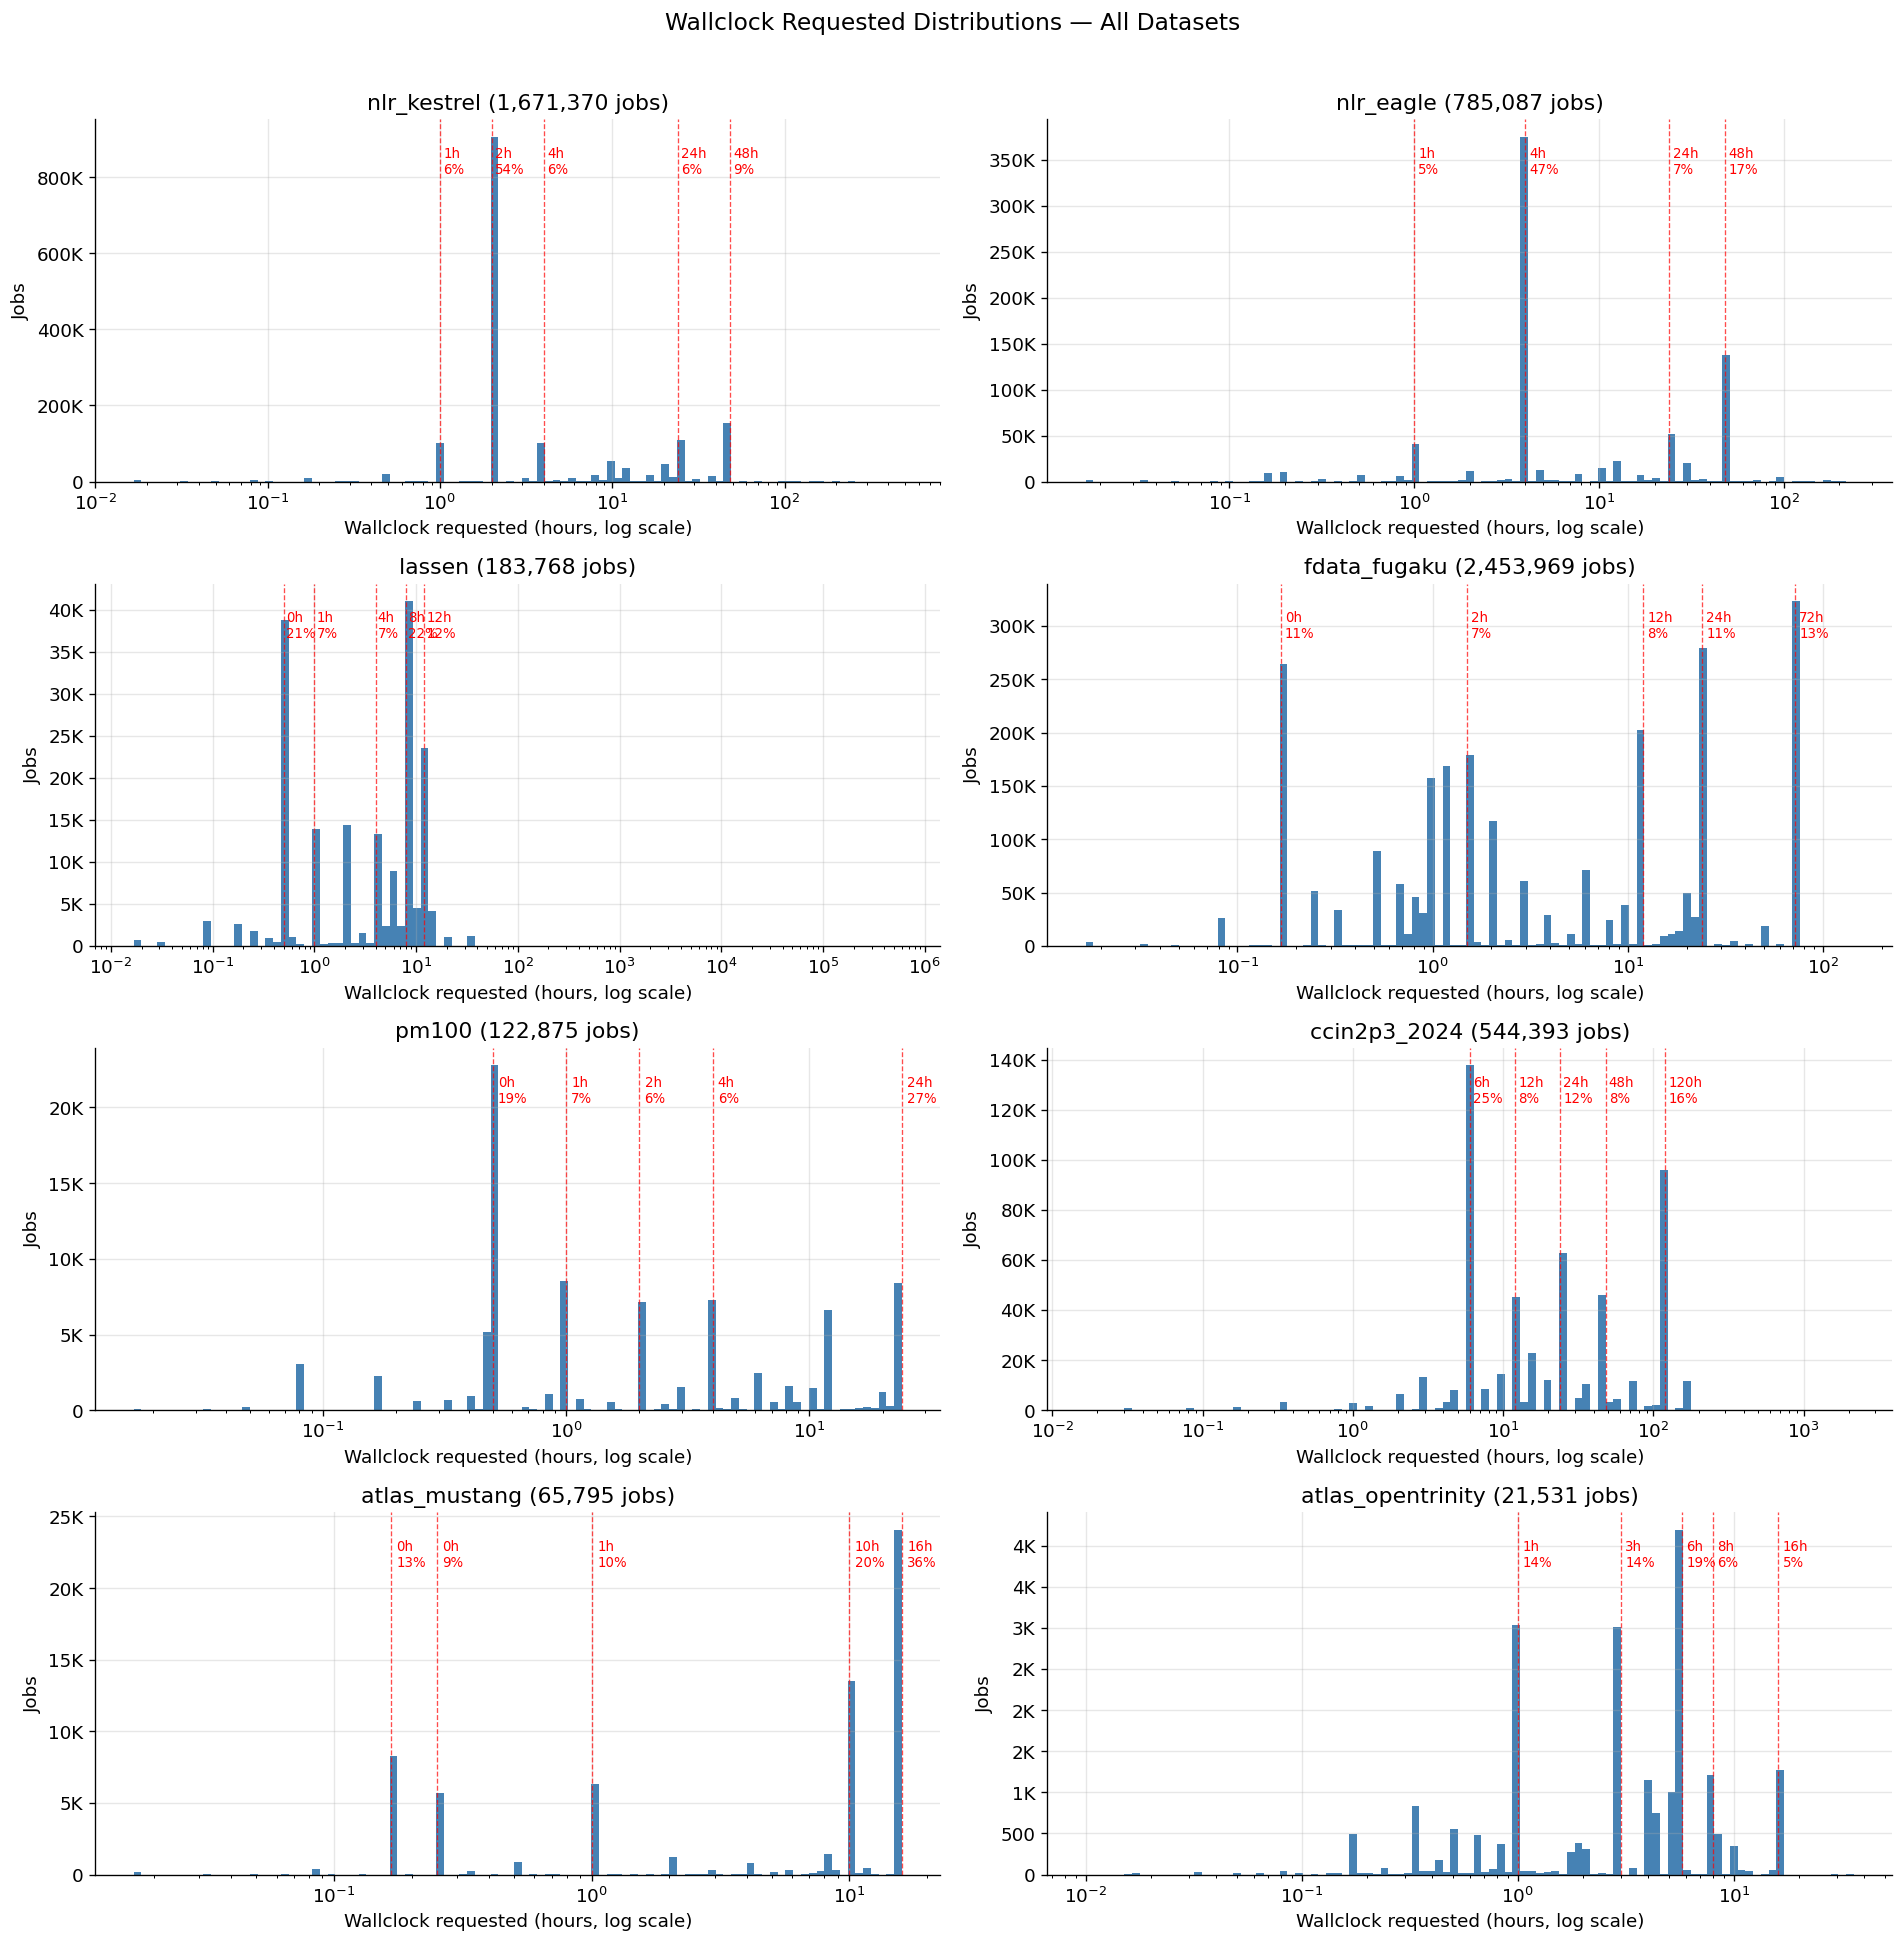

In [15]:
n_datasets = len(loaded)
n_cols = 2
n_rows_grid = (n_datasets + 1) // 2

fig, axes = plt.subplots(n_rows_grid, n_cols, figsize=(16, 4 * n_rows_grid))
axes = axes.flat

for idx, (name, data) in enumerate(loaded.items()):
    ax = axes[idx]
    wc_h = data['df']['wc_hours']
    
    # Log-scale histogram
    log_bins = np.logspace(np.log10(max(wc_h.min(), 0.01)), np.log10(wc_h.max()), 100)
    ax.hist(wc_h, bins=log_bins, color='steelblue', edgecolor='none')
    ax.set_xscale('log')
    ax.set_xlabel('Wallclock requested (hours, log scale)')
    ax.set_ylabel('Jobs')
    ax.set_title(f'{name} ({len(wc_h):,} jobs)')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1000 else f'{x:.0f}'))
    
    # Annotate top spikes
    # Find values where > 5% of jobs cluster (within ±2 min = ±0.033h)
    wc_min = (data['df'][data['wc_col']] / 60).round().astype(int)
    from collections import Counter
    counts = Counter(wc_min.values)
    total = len(wc_min)
    for mins, count in counts.most_common(5):
        pct = count / total * 100
        if pct >= 3:
            hours = mins / 60
            ax.axvline(hours, color='red', linestyle='--', alpha=0.7, linewidth=0.8)
            ax.text(hours * 1.05, ax.get_ylim()[1] * 0.85, f'{hours:.0f}h\n{pct:.0f}%',
                    fontsize=8, color='red')

# Hide unused subplots
for idx in range(n_datasets, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Wallclock Requested Distributions — All Datasets', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Heatmap: Requested Wallclock vs Actual Runtime

Each plot shows the density of jobs at each (requested_wallclock, actual_runtime) coordinate.
Both axes use log scale. The diagonal dashed line represents "used 100% of requested time."
Jobs below the diagonal finished early; jobs above it exceeded their request (rare — usually
the scheduler kills them at the limit).

Dense clusters at specific x-values (vertical bands) confirm the partition limit spikes.
The vertical spread within each band shows how variable actual runtime is for that wallclock group.

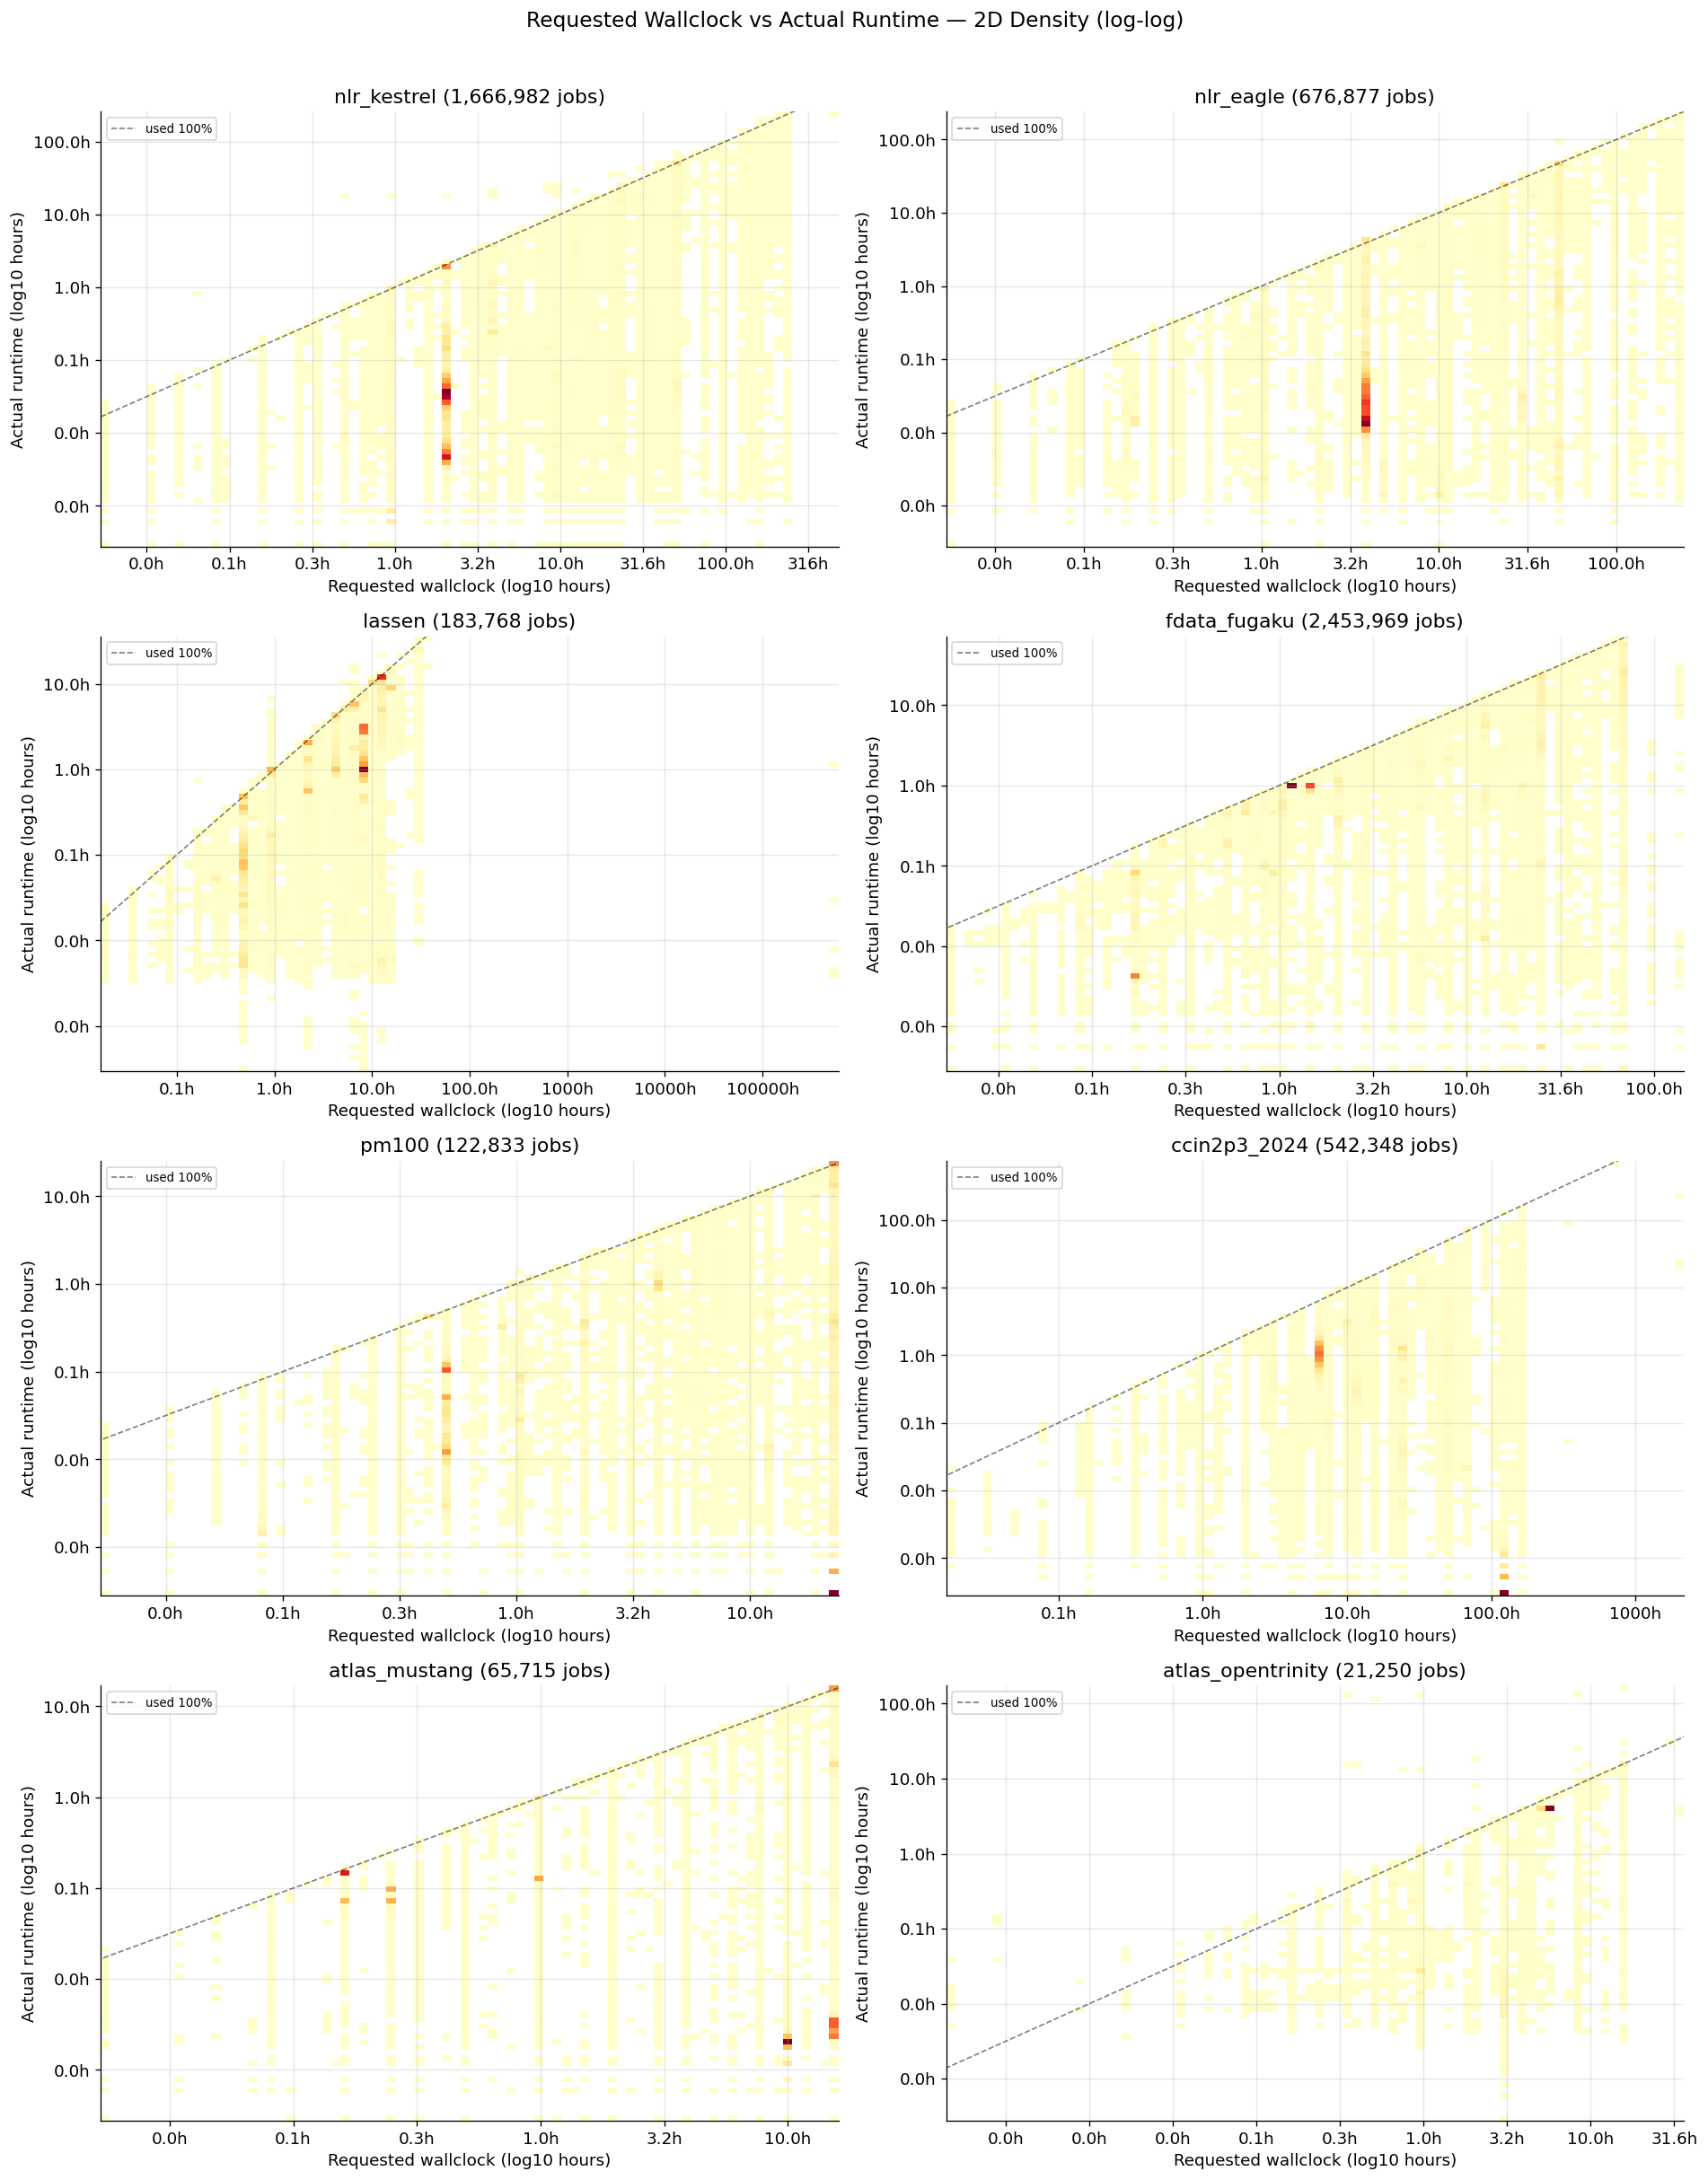

In [16]:
n_datasets = len(loaded)
n_cols = 2
n_rows_grid = (n_datasets + 1) // 2

fig, axes = plt.subplots(n_rows_grid, n_cols, figsize=(16, 5 * n_rows_grid))
axes = axes.flat

for idx, (name, data) in enumerate(loaded.items()):
    ax = axes[idx]
    df = data['df']
    wc_col = data['wc_col']
    
    wc = df[wc_col].values
    rt = df['runtime_seconds'].values
    # Filter to positive values for log scale
    valid = (wc > 0) & (rt > 0) & np.isfinite(wc) & np.isfinite(rt)
    wc_v, rt_v = wc[valid], rt[valid]
    
    # 2D histogram in log space
    h = ax.hist2d(
        np.log10(wc_v / 3600),  # x: log10(hours)
        np.log10(rt_v / 3600),  # y: log10(hours)
        bins=80,
        cmap='YlOrRd',
        cmin=1,
    )
    
    # Diagonal: used 100% of requested
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='used 100%')
    
    ax.set_xlabel('Requested wallclock (log10 hours)')
    ax.set_ylabel('Actual runtime (log10 hours)')
    ax.set_title(f'{name} ({len(wc_v):,} jobs)')
    
    # Readable tick labels
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(ticker.FuncFormatter(
            lambda x, _: f'{10**x:.1f}h' if x <= 2 else f'{10**x:.0f}h'))
    ax.legend(fontsize=8, loc='upper left')

for idx in range(n_datasets, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Requested Wallclock vs Actual Runtime — 2D Density (log-log)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Spike Detection

Identify exact wallclock values where a significant fraction (>1%) of jobs cluster.
These spikes correspond to partition time limits — the system's configured maximum
wallclock for each queue. The tolerance is ±2 minutes to catch slight rounding variations.

In [17]:
from collections import Counter

all_spikes = {}  # name -> list of (hours, count, pct)

for name, data in loaded.items():
    df = data['df']
    wc_col = data['wc_col']
    
    # Round to nearest minute
    wc_min = (df[wc_col] / 60).round().astype(int)
    total = len(wc_min)
    counts = Counter(wc_min.values)
    
    spikes = []
    for mins, count in counts.most_common(20):
        pct = count / total * 100
        if pct >= 1.0:  # threshold: >1% of jobs
            spikes.append((mins / 60, count, pct))
    
    all_spikes[name] = spikes
    
    print(f'\n=== {name} ({total:,} jobs) ===')
    print(f'{"Hours":>8} {"Count":>10} {"Percentage":>10}')
    print(f'{"-"*8} {"-"*10} {"-"*10}')
    for hours, count, pct in sorted(spikes, key=lambda x: -x[2]):
        print(f'{hours:>8.1f} {count:>10,} {pct:>9.1f}%')


=== nlr_kestrel (1,671,370 jobs) ===
   Hours      Count Percentage
-------- ---------- ----------
     2.0    907,175      54.3%
    48.0    146,669       8.8%
    24.0    108,207       6.5%
     4.0    101,082       6.0%
     1.0     98,241       5.9%
    10.0     52,959       3.2%
    20.0     46,752       2.8%
    12.0     34,702       2.1%
     0.5     19,908       1.2%

=== nlr_eagle (785,087 jobs) ===
   Hours      Count Percentage
-------- ---------- ----------
     4.0    371,712      47.3%
    48.0    133,298      17.0%
    24.0     51,691       6.6%
     1.0     39,488       5.0%
    12.0     22,477       2.9%
    30.0     20,633       2.6%
    10.0     14,957       1.9%
     5.0     12,422       1.6%
     2.0     11,516       1.5%
     0.2     10,667       1.4%
     0.2      9,499       1.2%

=== lassen (183,768 jobs) ===
   Hours      Count Percentage
-------- ---------- ----------
     8.0     40,948      22.3%
     0.5     38,138      20.8%
    12.0     22,827      12.4

## 5. Cross-Dataset Summary: Universal vs Site-Specific Boundaries

Which wallclock values appear across multiple datasets? Values like 24h and 48h are likely
universal HPC conventions, while others (e.g. Fugaku's 72h, Lassen's 0.5h) are site-specific.

In [18]:
# Collect all spikes into a cross-dataset table
from collections import defaultdict

boundary_datasets = defaultdict(list)  # hours -> list of (dataset, pct)
for name, spikes in all_spikes.items():
    for hours, count, pct in spikes:
        boundary_datasets[hours].append((name, pct))

# Sort by how many datasets share this boundary
boundaries = sorted(boundary_datasets.items(), key=lambda x: (-len(x[1]), x[0]))

print(f'{"Hours":>8} {"# Datasets":>10} {"Datasets (with % at this value)"}')
print(f'{"-"*8} {"-"*10} {"-"*50}')
for hours, datasets in boundaries:
    ds_str = ', '.join(f'{n} ({p:.0f}%)' for n, p in sorted(datasets, key=lambda x: -x[1]))
    print(f'{hours:>8.1f} {len(datasets):>10} {ds_str}')

print(f'\n--- Universal boundaries (appear in 3+ datasets) ---')
for hours, datasets in boundaries:
    if len(datasets) >= 3:
        print(f'  {hours:.1f}h — present in {len(datasets)} datasets')

   Hours # Datasets Datasets (with % at this value)
-------- ---------- --------------------------------------------------
     2.0          8 nlr_kestrel (54%), lassen (7%), pm100 (6%), fdata_fugaku (4%), atlas_mustang (2%), nlr_eagle (1%), atlas_opentrinity (1%), ccin2p3_2024 (1%)
    10.0          8 atlas_mustang (20%), nlr_kestrel (3%), ccin2p3_2024 (3%), lassen (2%), nlr_eagle (2%), atlas_opentrinity (2%), fdata_fugaku (1%), pm100 (1%)
     1.0          7 atlas_opentrinity (14%), atlas_mustang (10%), lassen (7%), pm100 (7%), fdata_fugaku (6%), nlr_kestrel (6%), nlr_eagle (5%)
     4.0          7 nlr_eagle (47%), lassen (7%), nlr_kestrel (6%), pm100 (6%), atlas_opentrinity (5%), atlas_mustang (1%), fdata_fugaku (1%)
     0.2          6 atlas_mustang (13%), fdata_fugaku (11%), atlas_opentrinity (2%), pm100 (2%), lassen (1%), nlr_eagle (1%)
     0.5          6 lassen (21%), pm100 (19%), fdata_fugaku (4%), atlas_opentrinity (3%), atlas_mustang (1%), nlr_kestrel (1%)
    12.0          

## 6. Partition × Wallclock Crosstab

For datasets with a `partition` field, show the maximum observed wallclock per partition.
This reveals the actual system partition configuration — each partition has a wallclock
ceiling that determines which spike its jobs cluster at.

In [19]:
partition_fields = ['partition', 'queue']  # some datasets use 'queue' instead

for name, data in loaded.items():
    df = data['df']
    wc_col = data['wc_col']
    
    part_col = None
    for pf in partition_fields:
        if pf in df.columns:
            part_col = pf
            break
    if part_col is None:
        continue
    
    print(f'\n=== {name} (partition field: {part_col}) ===')
    # Top partitions by job count
    top_parts = df[part_col].value_counts().head(10).index
    print(f'{"Partition":<25} {"Jobs":>8} {"Max WC (h)":>10} {"Median WC (h)":>12} {"Top WC value":>12}')
    print(f'{"-"*25} {"-"*8} {"-"*10} {"-"*12} {"-"*12}')
    for part in top_parts:
        subset = df[df[part_col] == part]
        wc_h = subset['wc_hours']
        top_val = wc_h.mode().iloc[0] if len(wc_h) > 0 else 0
        print(f'{str(part):<25} {len(subset):>8,} {wc_h.max():>10.1f} {wc_h.median():>12.1f} {top_val:>12.1f}h')


=== nlr_kestrel (partition field: partition) ===
Partition                     Jobs Max WC (h) Median WC (h) Top WC value
------------------------- -------- ---------- ------------ ------------
standard                  1,148,369       48.0          2.0          2.0h
short                      195,268        6.0          2.0          4.0h
gpu-h100                   103,327       48.0          4.0          1.0h
shared                      94,565       48.0         16.0         20.0h
gpu-h100-stdby              29,337       48.0         24.0         12.0h
standard-stdby              21,194       48.0         48.0         48.0h
shared-stdby                15,785       48.0          4.0          4.0h
debug                       15,049        4.0          1.0          1.0h
gpu-h100s                   14,809        4.0          2.0          2.0h
long                         7,434      480.0        106.0        240.0h

=== nlr_eagle (partition field: partition) ===
Partition                 

## 7. Within-Cluster Runtime Analysis

For each major spike (partition limit), analyze the runtime distribution of jobs that
requested exactly that wallclock value. This answers: if we trained a separate model for
each cluster, how much variance would each expert face?

Key metrics:
- **Median runtime** — the typical job duration in this cluster
- **p90/p10 ratio** — how spread out the runtimes are (lower = more predictable)
- **CV** — coefficient of variation (std/mean, lower = more uniform)
- **Utilization** — median(runtime) / requested_wallclock (how much time they actually use)

In [20]:
for name, data in loaded.items():
    df = data['df']
    wc_col = data['wc_col']
    spikes = all_spikes.get(name, [])
    if not spikes:
        continue
    
    print(f'\n=== {name} ===')
    print(f'{"WC (h)":>8} {"Jobs":>8} {"RT median":>10} {"RT p10":>8} {"RT p90":>10} '
          f'{"p90/p10":>8} {"CV":>6} {"Utilization":>12}')
    print('-' * 85)
    
    for hours, count, pct in sorted(spikes, key=lambda x: x[0]):
        wc_seconds = hours * 3600
        # Jobs at this spike (±2 min)
        mask = (df[wc_col] >= wc_seconds - 120) & (df[wc_col] <= wc_seconds + 120)
        rt = df.loc[mask, 'runtime_seconds'].dropna()
        rt = rt[rt > 0]
        if len(rt) < 10:
            continue
        
        p10, p50, p90 = rt.quantile([0.1, 0.5, 0.9])
        ratio = p90 / p10 if p10 > 0 else float('inf')
        cv = rt.std() / rt.mean() if rt.mean() > 0 else 0
        utilization = p50 / wc_seconds if wc_seconds > 0 else 0
        
        print(f'{hours:>8.1f} {len(rt):>8,} {p50:>10,.0f}s {p10:>8,.0f}s {p90:>10,.0f}s '
              f'{ratio:>8.0f}x {cv:>6.2f} {utilization:>11.1%}')


=== nlr_kestrel ===
  WC (h)     Jobs  RT median   RT p10     RT p90  p90/p10     CV  Utilization
-------------------------------------------------------------------------------------
     0.5   19,904         48s       24s      1,273s       52x   2.55        2.7%
     1.0   99,422         99s        2s      2,381s     1190x   1.68        2.8%
     2.0  906,875        115s       17s        795s       47x   3.06        1.6%
     4.0  101,557      1,105s       14s      8,519s      608x   1.45        7.7%
    10.0   52,520        174s       15s      2,160s      144x   3.34        0.5%
    12.0   34,668      8,680s      382s     43,200s      113x   1.03       20.1%
    20.0   46,496      1,533s       50s     27,944s      565x   1.66        2.1%
    24.0  109,721        615s       24s     53,398s     2225x   1.89        0.7%
    48.0  146,473      5,733s       21s    172,801s     8229x   1.52        3.3%

=== nlr_eagle ===
  WC (h)     Jobs  RT median   RT p10     RT p90  p90/p10     CV  U

## 8. Key Findings Per Dataset

For each dataset, summarize the most notable wallclock vs runtime relationships.
Focus on over-requesting patterns (users request much more time than they need)
and whether different wallclock clusters represent genuinely different job populations.

In [21]:
print('=== KEY FINDINGS: Wallclock Utilization Patterns ===\n')

for name, data in loaded.items():
    df = data['df']
    wc_col = data['wc_col']
    rt = df['runtime_seconds'].dropna()
    wc = df[wc_col].dropna()
    
    print(f'--- {name} ({len(df):,} jobs) ---')
    
    # Overall utilization
    valid = (wc > 0) & (rt > 0)
    utilization = (rt[valid] / wc[valid])
    print(f'  Overall wallclock utilization: median {utilization.median():.1%} '
          f'(users use {utilization.median()*100:.1f}% of what they request)')
    
    # Per-threshold analysis: for jobs requesting > X, what % finished under Y?
    thresholds_h = [2, 8, 24, 48]
    for th in thresholds_h:
        th_s = th * 3600
        requested_over = df[wc_col] >= th_s - 120  # at or above this threshold
        if requested_over.sum() < 100:
            continue
        actual = df.loc[requested_over, 'runtime_seconds'].dropna()
        actual = actual[actual > 0]
        if len(actual) < 100:
            continue
        
        # What fraction finished in less than half the threshold?
        under_half = (actual < th_s * 0.5).mean() * 100
        # What fraction finished in less than 10% of threshold?
        under_tenth = (actual < th_s * 0.1).mean() * 100
        median_actual_h = actual.median() / 3600
        
        print(f'  Jobs requesting >= {th}h ({requested_over.sum():,} jobs):')
        print(f'    Median actual runtime: {median_actual_h:.2f}h '
              f'({actual.median()/th_s*100:.1f}% of requested)')
        print(f'    {under_half:.0f}% finished in < {th/2:.0f}h (under half their request)')
        print(f'    {under_tenth:.0f}% finished in < {th*0.1:.1f}h (under 10% of their request)')
    
    # Distinct populations check
    spikes = all_spikes.get(name, [])
    if len(spikes) >= 2:
        top2 = sorted(spikes, key=lambda x: -x[2])[:2]
        h1, _, p1 = top2[0]
        h2, _, p2 = top2[1]
        s1 = h1 * 3600
        s2 = h2 * 3600
        rt1 = df.loc[(df[wc_col] >= s1 - 120) & (df[wc_col] <= s1 + 120), 'runtime_seconds'].dropna().median()
        rt2 = df.loc[(df[wc_col] >= s2 - 120) & (df[wc_col] <= s2 + 120), 'runtime_seconds'].dropna().median()
        if rt1 > 0 and rt2 > 0:
            ratio = max(rt1, rt2) / min(rt1, rt2)
            print(f'  Top 2 clusters: {h1:.0f}h ({p1:.0f}%) median_rt={rt1:.0f}s vs '
                  f'{h2:.0f}h ({p2:.0f}%) median_rt={rt2:.0f}s — {ratio:.1f}x difference')
    print()

=== KEY FINDINGS: Wallclock Utilization Patterns ===

--- nlr_kestrel (1,671,370 jobs) ---
  Overall wallclock utilization: median 1.7% (users use 1.7% of what they request)
  Jobs requesting >= 2h (1,526,001 jobs):
    Median actual runtime: 0.04h (2.1% of requested)
    80% finished in < 1h (under half their request)
    70% finished in < 0.2h (under 10% of their request)
  Jobs requesting >= 8h (488,565 jobs):
    Median actual runtime: 0.45h (5.6% of requested)
    72% finished in < 4h (under half their request)
    55% finished in < 0.8h (under 10% of their request)
  Jobs requesting >= 24h (292,535 jobs):
    Median actual runtime: 0.72h (3.0% of requested)
    78% finished in < 12h (under half their request)
    62% finished in < 2.4h (under 10% of their request)
  Jobs requesting >= 48h (155,276 jobs):
    Median actual runtime: 1.73h (3.6% of requested)
    80% finished in < 24h (under half their request)
    60% finished in < 4.8h (under 10% of their request)
  Top 2 clusters

## 9. Variance Reduction Analysis

Compare the global runtime variance (all jobs together) vs per-cluster variance
(jobs grouped by wallclock spike). If per-cluster variance is much lower, a separate
model per cluster would face a simpler prediction problem.

**Metric: Coefficient of Variation (CV)** = standard deviation / mean.
- CV of 1.0 means the spread is as large as the average
- CV of 4.0 means the data is extremely spread out (typical for HPC runtimes globally)
- Lower CV = more predictable, easier for a model to learn

**CV Reduction** = how much lower the per-cluster CV is compared to the global CV.
- Positive reduction (e.g. -30% CV) = clustering helps, prediction is easier per-cluster
- Near-zero reduction = clustering doesn't reduce variance much

In [22]:
print(f'{"Dataset":<20} {"Global CV":>10} {"Mean Cluster CV":>15} {"CV Reduction":>12} {"Interpretation"}')
print('-' * 85)

variance_results = []

for name, data in loaded.items():
    df = data['df']
    wc_col = data['wc_col']
    spikes = all_spikes.get(name, [])
    
    # Global CV
    rt_all = df['runtime_seconds'].dropna()
    rt_all = rt_all[rt_all > 0]
    global_cv = rt_all.std() / rt_all.mean()
    
    # Per-cluster CV (weighted by cluster size)
    cluster_cvs = []
    cluster_sizes = []
    for hours, count, pct in spikes:
        wc_s = hours * 3600
        mask = (df[wc_col] >= wc_s - 120) & (df[wc_col] <= wc_s + 120)
        rt = df.loc[mask, 'runtime_seconds'].dropna()
        rt = rt[rt > 0]
        if len(rt) < 10 or rt.mean() == 0:
            continue
        cv = rt.std() / rt.mean()
        cluster_cvs.append(cv)
        cluster_sizes.append(len(rt))
    
    if cluster_cvs:
        # Weighted mean CV
        weights = np.array(cluster_sizes) / sum(cluster_sizes)
        weighted_cv = np.average(cluster_cvs, weights=weights)
        reduction = (1 - weighted_cv / global_cv) * 100
        
        if reduction > 30:
            interp = 'Strong benefit from per-cluster models'
        elif reduction > 10:
            interp = 'Moderate benefit'
        else:
            interp = 'Minimal benefit — clusters still very variable'
        
        print(f'{name:<20} {global_cv:>10.2f} {weighted_cv:>15.2f} {reduction:>11.0f}% {interp}')
        variance_results.append({'name': name, 'global_cv': global_cv, 
                                  'cluster_cv': weighted_cv, 'reduction_pct': reduction})
    else:
        print(f'{name:<20} {global_cv:>10.2f} {"N/A":>15} {"—":>12} No valid clusters')

print()
print('Note: CV reduction measures how much SIMPLER the prediction problem becomes')
print('when you know which wallclock cluster a job belongs to. Higher = more benefit')
print('from mixture-of-experts. But even with reduction, per-cluster CV may still be high.')

Dataset               Global CV Mean Cluster CV CV Reduction Interpretation
-------------------------------------------------------------------------------------
nlr_kestrel                4.29            2.54          41% Strong benefit from per-cluster models
nlr_eagle                  4.09            2.40          41% Strong benefit from per-cluster models
lassen                     1.67            0.91          46% Strong benefit from per-cluster models
fdata_fugaku               2.32            0.89          62% Strong benefit from per-cluster models
pm100                      2.83            1.55          45% Strong benefit from per-cluster models
ccin2p3_2024               3.36            3.71         -10% Minimal benefit — clusters still very variable
atlas_mustang              2.75            2.53           8% Minimal benefit — clusters still very variable
atlas_opentrinity          2.13            3.66         -72% Minimal benefit — clusters still very variable

Note: CV redu

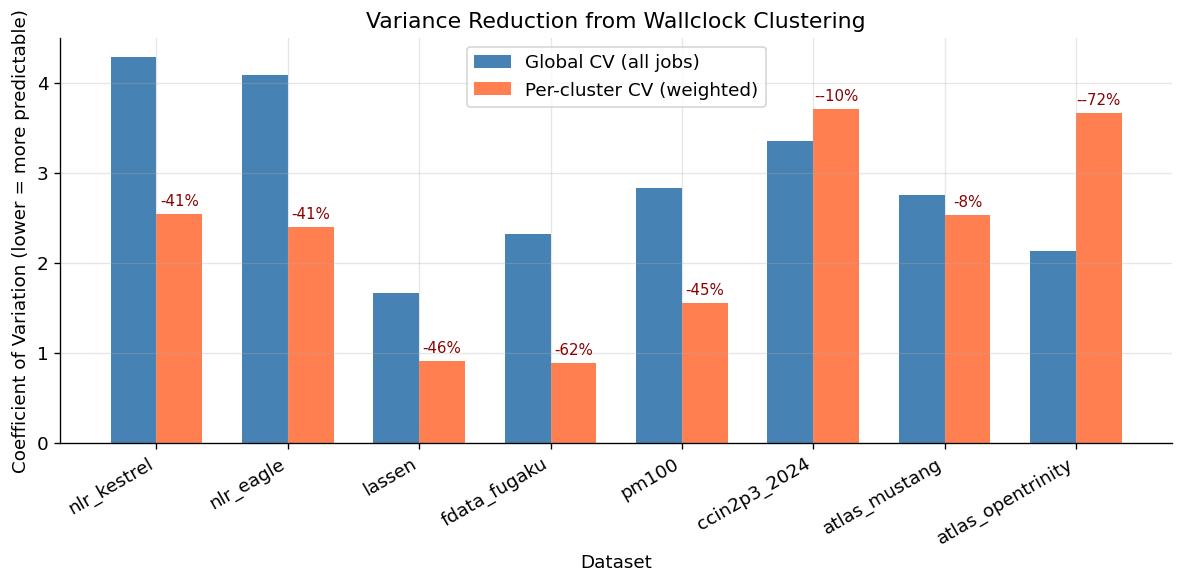

In [23]:
# Visualize: global CV vs per-cluster CV
if variance_results:
    fig, ax = plt.subplots(figsize=(10, 5))
    names = [r['name'] for r in variance_results]
    global_cvs = [r['global_cv'] for r in variance_results]
    cluster_cvs = [r['cluster_cv'] for r in variance_results]
    
    x = np.arange(len(names))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, global_cvs, width, label='Global CV (all jobs)', color='steelblue')
    bars2 = ax.bar(x + width/2, cluster_cvs, width, label='Per-cluster CV (weighted)', color='coral')
    
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Coefficient of Variation (lower = more predictable)')
    ax.set_title('Variance Reduction from Wallclock Clustering')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right')
    ax.legend()
    
    # Annotate reduction percentages
    for i, r in enumerate(variance_results):
        ax.annotate(f'{r["reduction_pct"]:+.0f}% CV' if r['reduction_pct'] < 0 else f'-{r["reduction_pct"]:.0f}% CV',
                    xy=(i + width/2, r['cluster_cv']),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=9, color='darkred')
    
    plt.tight_layout()
    plt.show()

## 10. Conclusions & Next Steps

Summary of findings from this analysis.

In [24]:
print('=' * 80)
print('WALLCLOCK DISTRIBUTION ANALYSIS — CONCLUSIONS')
print('=' * 80)

print('''
1. WALLCLOCK VALUES CLUSTER STRONGLY AT PARTITION LIMITS
   Every dataset shows discrete spikes at round-number hours (1h, 2h, 4h, 8h, 12h,
   24h, 48h, 72h). These are not arbitrary — they are the configured wallclock ceilings
   of each system's partitions. Users request at or near the maximum allowed.

2. THESE CLUSTERS REPRESENT DIFFERENT JOB POPULATIONS
   Jobs requesting 2h have very different median runtimes than jobs requesting 48h.
   The top-2 cluster median runtime ratios show 10x–50x differences between the
   dominant short-wallclock and long-wallclock populations.

3. USERS MASSIVELY OVER-REQUEST WALLCLOCK TIME
   Median utilization is typically 1–5% of the requested wallclock.
   Even for long requests (>24h), 70–90% of jobs finish in under half their request.
   This is rational user behavior — requesting more is free, running out kills the job.

4. VARIANCE REDUCTION FROM CLUSTERING IS MODERATE, NOT TRANSFORMATIVE
   Per-cluster CV is lower than global CV, but the within-cluster spread is still large
   (p90/p10 ratios of 50x–6000x within a single cluster). Clustering helps but doesn't
   solve the prediction problem on its own.

5. SOME BOUNDARIES ARE UNIVERSAL, OTHERS ARE SITE-SPECIFIC
   24h and 48h appear across most datasets. 72h is Fugaku-specific. 0.5h is Lassen-specific.
   A mixture-of-experts system would need either site-specific configuration or dynamic
   boundary detection.

NEXT STEPS:
  a) Run the 4-way comparison experiment (no wallclock → with wallclock → with partition
     → per-cluster experts) to determine if separate models add value beyond what a single
     XGBoost tree already captures through its splits.
  b) Use the detected spikes as natural bin boundaries for the proof-of-concept.
  c) Consider that the moderate variance reduction means per-cluster models may help
     MAE but won't eliminate the fundamental prediction challenge of heavy-tailed runtimes.
  d) The log_target and pseudohuber loss (issue #123) may interact beneficially with
     clustering — a per-cluster model with log_target faces an even simpler problem.
''')

WALLCLOCK DISTRIBUTION ANALYSIS — CONCLUSIONS

1. WALLCLOCK VALUES CLUSTER STRONGLY AT PARTITION LIMITS
   Every dataset shows discrete spikes at round-number hours (1h, 2h, 4h, 8h, 12h,
   24h, 48h, 72h). These are not arbitrary — they are the configured wallclock ceilings
   of each system's partitions. Users request at or near the maximum allowed.

2. THESE CLUSTERS REPRESENT DIFFERENT JOB POPULATIONS
   Jobs requesting 2h have very different median runtimes than jobs requesting 48h.
   The top-2 cluster median runtime ratios show 10x–50x differences between the
   dominant short-wallclock and long-wallclock populations.

3. USERS MASSIVELY OVER-REQUEST WALLCLOCK TIME
   Median utilization is typically 1–5% of the requested wallclock.
   Even for long requests (>24h), 70–90% of jobs finish in under half their request.
   This is rational user behavior — requesting more is free, running out kills the job.

4. VARIANCE REDUCTION FROM CLUSTERING IS MODERATE, NOT TRANSFORMATIVE
   Per-c